In [1]:
import os, csv
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

import baltic as bt
from baltic.bt_utils import desaturate_cmap, plot_scale_bar, clean_axes

typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

############# load data
basePath = '/mnt/c/Users/evogytis/repos/baltic-v1-manuscript/'
rtFile = 'data/Fig4_tanglegrams/psi_blast_rt_1000_cdhit0.7_20241119.fasta.aln.treefile'
tpFile = 'data/Fig4_tanglegrams/psi_blast_toprim_1000_cdhit0.7_20241119.fasta.aln.treefile'
accFile = 'data/Fig4_tanglegrams/retron_accessions.tsv'
####

def plot_unrooted_tanglegram(ax, treeA=os.path.join(basePath, rtFile), treeB=os.path.join(basePath, tpFile), classificationFile=os.path.join(basePath, accFile)):
    
    rt = bt.io.load_newick(treeA, 'divergence')
    rt.treeStats()
    ####
    
    tp = bt.io.load_newick(treeB, 'divergence')
    tp.treeStats()
    
    ####
    classification={}
    
    for l in csv.DictReader(open(classificationFile, 'r'), delimiter='\t'):
        acc = l['Accesione']
        retroType = l['Retron (sub)b']
    
        classification[acc] = retroType
    
    ###### plot unrooted trees
    rotation = 0.25
    branchWidth = 1.5
    rt.plot_tree(ax, treeType='unrooted', circStart=rotation, width=branchWidth)
    
    xAttr = lambda k: k.x - 0.1 ## one tree is offset along x axis
    yAttr = lambda k: k.y - 2.0 ## one tree is offset along x axis
    
    tp.plot_tree(ax, treeType='unrooted', circStart=rotation, width=branchWidth, xCoordinateFxn=xAttr, yCoordinateFxn=yAttr)
    
    ################# get tip overlap between trees
    rtTips = set(['_'.join(q.split('_')[:-1]) for q in rt.get_parameter_list('name')])
    tpTips = set(['_'.join(q.split('_')[:-1]) for q in tp.get_parameter_list('name')])
    
    overlap = rtTips.intersection(tpTips) ## tips present in both trees
    
    ######### assign colours
    cmap = desaturate_cmap(mpl.cm.Spectral, 0.7)
    tipColours = {}

    tipTraversalOrder = {k: i for i, k in enumerate(rt.traverse_tree())}
    
    for k in rt.get_external():
        frac = tipTraversalOrder[k] / (len(tipTraversalOrder) - 1)
        fmtName = '_'.join(k.name.split('_')[:-1])
        
        if fmtName in overlap: ## overlapping tips
            fc = cmap(frac)
            tipColours[fmtName] = fc
        else:
            tipColours[fmtName] = 'lightgray'
    
    for k in tp.get_external(): ## not overlapping tips
        fmtName = '_'.join(k.name.split('_')[:-1])
        if fmtName not in overlap and fmtName not in tipColours: ## not overlapping tips
            tipColours[fmtName] = 'lightgray'
    
    #### tip circles on both trees
    overlapTargetFxn = lambda k: k.is_leaf() and '_'.join(k.name.split('_')[:-1]) in overlap
    colourFxn = lambda k: tipColours['_'.join(k.name.split('_')[:-1])]
    
    rt.plot_points(ax, treeType='unrooted', circStart=rotation, targetFxn=overlapTargetFxn, colourFxn=colourFxn, pointSize=20, zorder=100)
    tp.plot_points(ax, treeType='unrooted', circStart=rotation, targetFxn=overlapTargetFxn, colourFxn=colourFxn, xCoordinateFxn=xAttr, yCoordinateFxn=yAttr, pointSize=20, zorder=100)
    
    ###
    nonoverlapTargetFxn = lambda k: k.is_leaf() and '_'.join(k.name.split('_')[:-1]) not in overlap
    
    rt.plot_points(ax, treeType='unrooted', circStart=rotation, colourFxn=colourFxn, targetFxn=nonoverlapTargetFxn, pointSize=10, zorder=10)
    tp.plot_points(ax, treeType='unrooted', circStart=rotation, colourFxn=colourFxn, targetFxn=nonoverlapTargetFxn, xCoordinateFxn=xAttr, yCoordinateFxn=yAttr, pointSize=10, zorder=10)
    
    ################# connection lines
    for k in rt.get_external():
        nameA = '_'.join(k.name.split('_')[:-1])
        match = tp.get_external(lambda q: '_'.join(q.name.split('_')[:-1]) == nameA)
    
        if len(match) > 0:
            fc = tipColours[nameA]
            x1, y1 = k.x, k.y
            x2, y2 = xAttr(match[0]), yAttr(match[0])
    
            ax.plot([x1, x2],[y1, y2], ls='-', color=fc, alpha=0.7, lw=1, zorder=0)
    
    ###### tree labels
    ax.text(1.5, 0.4, 'RT', size=30, ha='center', va='top')
    ax.text(1.6, -4.4, 'TOPRIM', size=30, ha='center', va='top')
    
    #### scale bar
    x = -1.3
    y = -4.2
    L = 0.4
    
    plot_scale_bar(ax=ax, L=L, xy=(x, y), textXY=(x + L / 2, y - 0.05), textKwargs={'ha': 'center', 'va': 'top'}, tree=rt, unitText='aa subs/site', style='fancy')
    #### clean up axes
    clean_axes(ax)

    ax.text(0.01, 0.99, 'B', size=46, ha='left', va='top', transform=ax.transAxes)

    ax.set_xlim(-1.63, 2.29)
    ax.set_ylim(-4.5, 0.65)
    return ax
# ax.set_aspect(1)
plt.show()


Tree height: 1.898745
Tree length: 141.438573

Numbers of objects in tree: 820 (409 nodes and 411 leaves)


Tree height: 3.776181
Tree length: 204.894256

Numbers of objects in tree: 1000 (499 nodes and 501 leaves)



/mnt/c/Users/evogytis/repos/baltic/baltic/bt_utils.py:796: UserWarning: Both L and tree provided; L takes precedence.
  warnings.warn("Both L and tree provided; L takes precedence.")


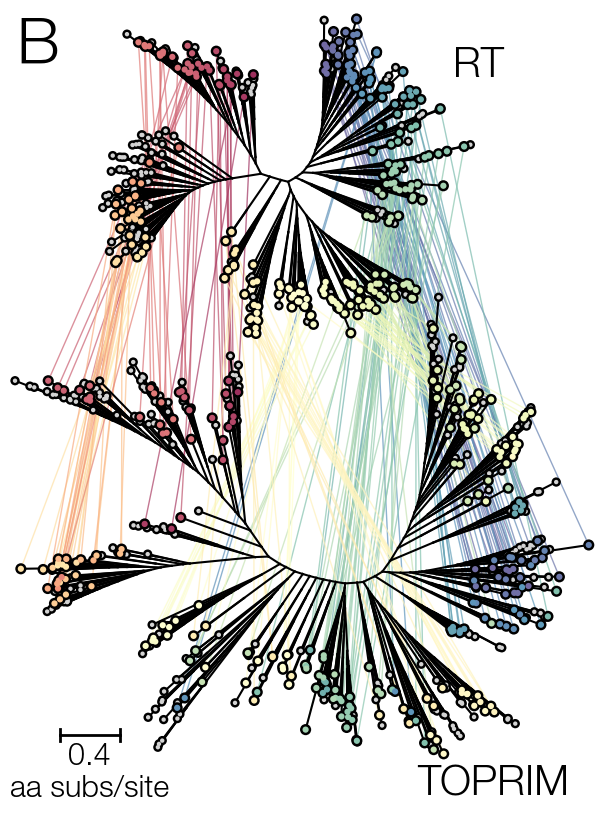

In [2]:
fig = plt.figure(figsize=(15, 10), facecolor='w')
gs = GridSpec(1, 1, hspace=0.01, wspace=0.05)

ax = plt.subplot(gs[0])
######

plot_unrooted_tanglegram(ax=ax)

plt.show()

In [3]:
def plot_fluB(ax, treeFiles):
    from baltic.bt_utils import make_cmap, plot_scale_bar
    from baltic.curonia import plot_tangled_chain
    ############# load data
    segTrees = {}
    
    vicCmap = make_cmap(["#4f000b","#720026","#ce4257","#ff7f51","#ff9b54"])
    yamCmap = make_cmap(["#022b3a","#1f7a8c","#bfdbf7"])
    colours = {}
    
    for idx, treeFile in enumerate(treeFiles):
        ll = bt.io.load_nexus(treeFile, 'time', tipRegex='_([0-9-]+)$')
        ll.treeStats()
        
        if idx == 0:
            subsampledTips = [k.name for i, k in enumerate(ll.get_external()) if i % 3 == 0]
    
        ll = ll.reduce_tree([k for k in ll.get_external() if k.name in subsampledTips])
        ll.sort_branches()
        ll._assign_tree_coordinates()
    
        if idx == 0:
            yamTips = sorted(ll.get_external(lambda k: k.traits['HA'] == 'Y'), key=lambda w: w.y)
            vicTips = sorted(ll.get_external(lambda k: k.traits['HA'] == 'V'), key=lambda w: w.y)
            
            for k in ll.get_external():
                if k in yamTips:
                    colours[k.name] = yamCmap(yamTips.index(k) / (len(yamTips) - 1))
                elif k in vicTips:
                    colours[k.name] = vicCmap(vicTips.index(k) / (len(vicTips) - 1))
        
        segTrees[treeFile] = ll

    treeList = [segTrees[treeFile] for treeFile in treeFiles]
    
    plot_tangled_chain(ax=ax, treeList=treeList, treeSpace=20, colourDict=colours, pointKwargs={'pointSize': 10, 'colourFxn': lambda k: colours[k.name]})

    x = 2.0
    y = 0.2
    plot_scale_bar(ax=ax, xy=(x, y), textXY=(x + 5.0, y + 0.004), textKwargs={'va': 'bottom'}, tree=treeList[0], fancyWidth=0.0005, style='fancy')
    clean_axes(ax)

    ax.text(0.01, 0.01, 'A', size=46, ha='left', va='bottom', transform=ax.transAxes)
    ax.set_xlim(0, sum([tree.treeHeight for tree in treeList]) + 20 * (len(treeList) - 1))
    ax.set_ylim(-0.01, 1.01)
    return ax


Tree height: 28.071359
Tree length: 481.049928
strictly bifurcating tree
annotations present

Numbers of objects in tree: 903 (451 nodes and 452 leaves)


Tree height: 30.210110
Tree length: 484.851289
strictly bifurcating tree
annotations present

Numbers of objects in tree: 903 (451 nodes and 452 leaves)


Tree height: 30.415856
Tree length: 449.376345
strictly bifurcating tree
annotations present

Numbers of objects in tree: 903 (451 nodes and 452 leaves)



/mnt/c/Users/evogytis/repos/baltic/baltic/bt_utils.py:822: UserWarning: No units provided; assuming branch lengths are years.
  warnings.warn("No units provided; assuming branch lengths are years.")


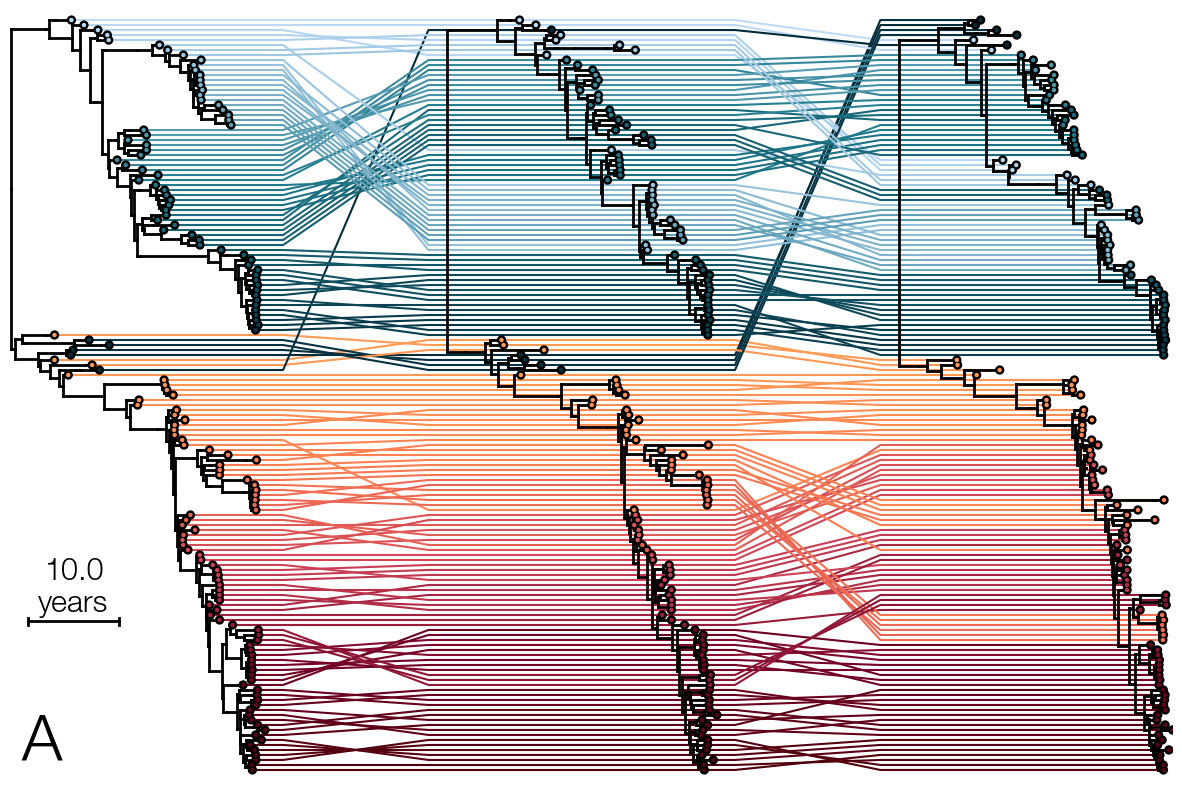

In [4]:
fig = plt.figure(figsize=(15, 10), facecolor='w')
gs = GridSpec(1, 1, hspace=0.01, wspace=0.05)

ax = plt.subplot(gs[0])
######
segments = ['PB1', 'PB2', 'HA']
treeFiles = [os.path.join(basePath, 'data/Fig4_tanglegrams', f"InfB_{seg}t_ALLs1.mcc.tre") for seg in segments]

plot_fluB(ax=ax, treeFiles=treeFiles)

plt.show()


Tree height: 28.071359
Tree length: 481.049928
strictly bifurcating tree
annotations present

Numbers of objects in tree: 903 (451 nodes and 452 leaves)


Tree height: 30.210110
Tree length: 484.851289
strictly bifurcating tree
annotations present

Numbers of objects in tree: 903 (451 nodes and 452 leaves)


Tree height: 30.415856
Tree length: 449.376345
strictly bifurcating tree
annotations present

Numbers of objects in tree: 903 (451 nodes and 452 leaves)



/mnt/c/Users/evogytis/repos/baltic/baltic/bt_utils.py:822: UserWarning: No units provided; assuming branch lengths are years.
  warnings.warn("No units provided; assuming branch lengths are years.")



Tree height: 1.898745
Tree length: 141.438573

Numbers of objects in tree: 820 (409 nodes and 411 leaves)


Tree height: 3.776181
Tree length: 204.894256

Numbers of objects in tree: 1000 (499 nodes and 501 leaves)



/mnt/c/Users/evogytis/repos/baltic/baltic/bt_utils.py:796: UserWarning: Both L and tree provided; L takes precedence.
  warnings.warn("Both L and tree provided; L takes precedence.")


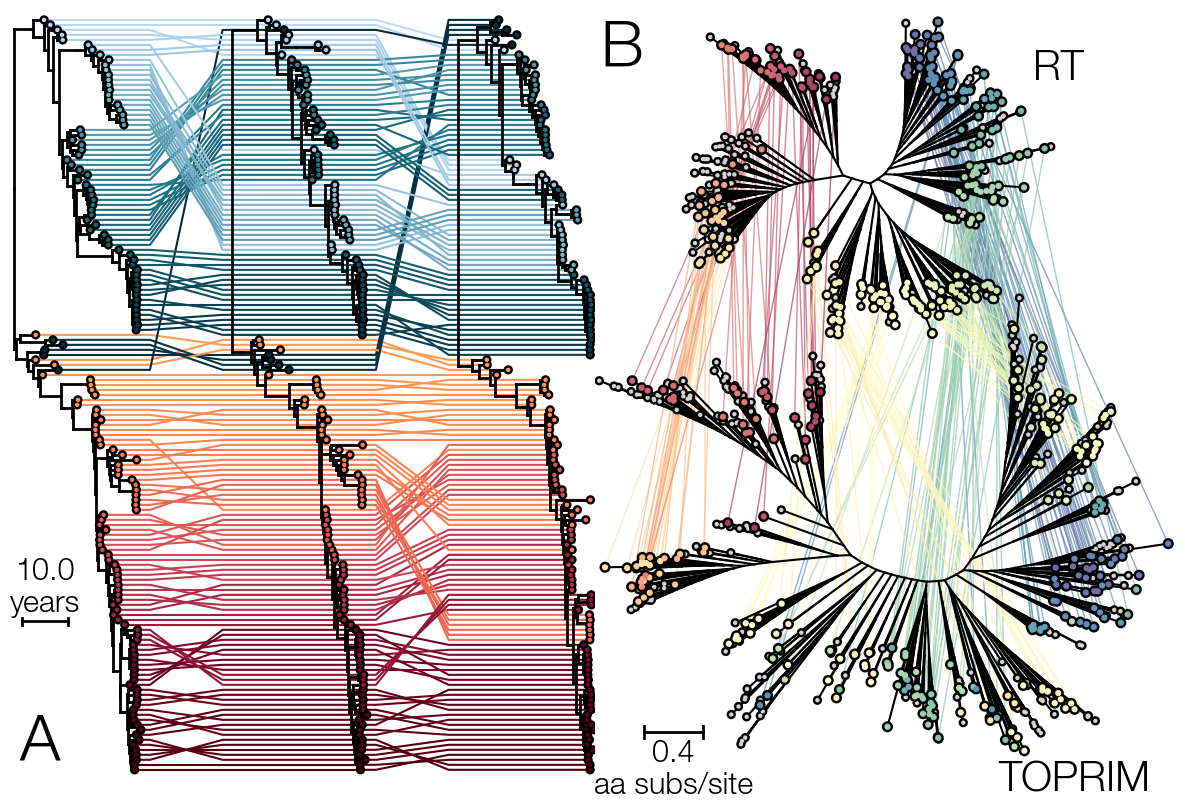

In [5]:
fig = plt.figure(figsize=(15, 10), facecolor='w')
gs = GridSpec(1, 2, width_ratios=[1, 1], hspace=0.01, wspace=0.0)

ax = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])
########

segments = ['PB1', 'PB2', 'HA']
treeFiles = [os.path.join(basePath, 'data/Fig4_tanglegrams', f"InfB_{seg}t_ALLs1.mcc.tre") for seg in segments]

plot_fluB(ax=ax, treeFiles=treeFiles)
###

plot_unrooted_tanglegram(ax=ax2)
###
######
plt.savefig(os.path.join(basePath, 'figures/Fig4_tanglegrams.png'), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(basePath, 'figures/Fig4_tanglegrams.pdf'), bbox_inches='tight', dpi=300)
plt.show()